In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [ ]:
(train_images,train_labels),(val_images,val_labels) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
(train_images,train_labels),(val_images,val_labels) = tf.keras.datasets.cifar10.load_data()

In [ ]:
train_images=train_images.astype('float32')/255.0
val_images=val_images.astype('float32')/255.0

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable=False

In [ ]:
model = models.Sequential([
    tf.keras.layers.Resizing(224,224),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_images,train_labels)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.7669 - loss: 0.6731


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models,Model

(train_images,train_labels),(val_images,val_labels) = tf.keras.datasets.cifar10.load_data()

train_images = train_images.astype('float32')/255.0
val_images = val_images.astype('float32')/255.0

base_model = tf.keras.applications.VGG16(
    input_shape=(32,32,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable=False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128,activation='relu')(x)
outputs = layers.Dense(10,activation='sigmoid')(x)

model = Model(inputs=base_model.input,outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(train_images,train_labels,epochs=1,validation_split=0.1)
model.evaluate(val_images,val_labels)

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5186 - loss: 1.3826 - val_accuracy: 0.5688 - val_loss: 1.2253
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5575 - loss: 1.2680


[1.2680023908615112, 0.5575000047683716]

Fine Tuning


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models


(train_images,train_labels),(val_images,val_labels) = tf.keras.datasets.cifar10.load_data()

train_images = train_images.astype('float32')/255.0
val_images = val_images.astype('float32')/255.0

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False   # ❄️ freeze initially

In [ ]:
model = models.Sequential([
    tf.keras.layers.Resizing(224,224),
    base_model,
    layers.GlobalMaxPooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    train_labels,
)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.7128 - loss: 0.8843


In [ ]:
base_model.trainable=True

for layer in base_model.layers[:-30]:
  layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_tune_history = model.fit(
    train_images,
    train_labels
)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 37ms/step - accuracy: 0.7500 - loss: 0.7264


________________________________________________________________________________________________________________________________________________________________________

In [ ]:
import tensorflow
from tensorflow.keras import layers,models

In [ ]:
(train_images,train_labels),(val_images,val_labels)=tf.keras.datasets.cifar10.load_data()

In [ ]:
train_images=train_images.astype('float32')/255.0
val_images=val_images.astype('float32')/255.0

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable=False

In [ ]:
model = models.Sequential([
    tf.keras.layers.Resizing(224,224),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(train_images,train_labels)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.7711 - loss: 0.6642


In [ ]:
base_model.trainable=True

for layers in base_model.layers[:-30]:
  layers.trainable=False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_tune_history=model.fit(train_images,train_labels)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 37ms/step - accuracy: 0.7884 - loss: 0.6081


# Image Segmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.random.rand(100,128,128,3)
y = np.random.randint(1,2,(100,128,128,1))

In [ ]:
def unet_model(input_size=(128, 128, 3)):

    inputs = layers.Input(input_size)

    # ---------------- Encoder ----------------
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    # ---------------- Bottleneck ----------------
    b1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)

    # ---------------- Decoder ----------------
    u1 = layers.UpSampling2D((2,2))(b1)
    u1 = layers.Concatenate()([u1, c1])

    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c2)

    model = models.Model(inputs, outputs)
    return model

In [ ]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(x, y, epochs=5, batch_size=8)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.9456 - loss: 0.1038
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 1.6296e-13
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 1.0935e-23
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 1.2861e-27
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 9.2514e-29


In [ ]:
pred = model.predict(x[:1])

pred_mask = (pred[0, :, :, 0]).astype("float32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


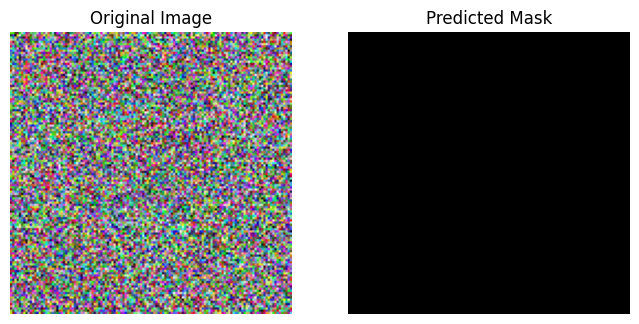

In [ ]:
# ----------------------------
# VISUALIZATION
# ----------------------------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(x[0])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")

plt.show()